# Explain Step Tutorial


## What you'll learn
1. Theory Primer <br>
2. How to run explain step <br>
3. How to customize the explain step <br>
4. Using LLMs to get biological insights of the latent dimensions <br>

### 1) Theory Primer
TODO

### 2) How To Perform the Explain Step
First, we need to run an AUTOENCODIX pipeline, `Ontix` is a very good choice here.
#### ❗❗ Requirements: Getting Tutorial Data ❗❗
To follow along, please download the date from the link below (1GB):

https://cloud.scadsai.uni-leipzig.de/index.php/s/HcaB8csTctGimQQ/download/OntixTutorialData.zip

After downloading:
- from the root of the repository, create the folders `data/raw` if not created yet
- move the donwloaded files there

#### Extra 2: Get correct path
We assume you are in the root of the package. The following code ensures that the correct paths are used.
[1] Tutorials/DeepDives/ConfigTutorial.ipynb


In [1]:
# Setting CUBLAS for reproducibility if you train on GPU
%env CUBLAS_WORKSPACE_CONFIG=:16:8

env: CUBLAS_WORKSPACE_CONFIG=:16:8


In [2]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")


Changed to: /home/ewald/Github/acx_main_releases/autoencodix_package


### 2a) Creating a synthetic ground truth
Feature importance by attribution scores is hard to quantify for its performance and reliability of outcome. Hence, we will introduce in this tutorial a little synthetic signal on selected genes of a specific chromosome only for a group of sample to check if they will be picked up by our xAI method.
Hence, we will alter the gene expression and methylation intensities of some genes of the 21 Chromosome only for 'male' samples (compare also Ontix tutorial).

In [3]:
import numpy as np
import pandas as pd
### Test with synthetic signal ###

def synth_signal(df, feature_list, sample_list):
	max_q90 = df.stack().quantile(0.9) # Our signal expression
	for sample in sample_list:
			df.loc[sample, feature_list] = max_q90*4 + np.random.normal(loc=0, scale=max_q90 * 0.25) # Add some noise to the signal
	return df

# Some genes on chromosome 21 which we will alter
# be aware that some will be filtered out during preprocessing by variance filtering
feature_synth = [
	"102724219",	# 21:p12
	"105379499",	# 21:p12
	"246312",	# 21:q21.1
	"105372749",	# 21:q21.2
	"266917",	# 21:q21.2
	"5651",	# 21:q21.1
	"105369292",	# 21:q21.1
	"102724951",	# 21:p11.2
	"1525",	# 21:q21.1
	"101927843",	# 21:q21.1
	"378828",	# 21:q21.1
	"118421",	# 21:q21.3
	"284825",	# 21:q21.3
	"101927869",	# 21:q21.2
	"9875",	# 21:q22.11
	"100874059",	# 13:q12.3
	"100131902",	# 21:q22.11
	"58494",	# 21:q21.3
	"105372746",	# 21:q21.1
]

df_rna = pd.read_parquet("data/raw/"+"combined_rnaseq_formatted.parquet")
df_meth = pd.read_parquet("data/raw/"+"combined_meth_formatted.parquet")
df_anno = pd.read_parquet("data/raw/"+"combined_clin_formatted.parquet")

sample__intersection = df_rna.index.intersection(df_meth.index).intersection(df_anno.index)
sample_group = "Male"
sample_synth = df_anno.loc[df_anno["SEX"] == sample_group].index.intersection(sample__intersection).to_list()

df_rna = synth_signal(df_rna, feature_list=feature_synth, sample_list=sample_synth)
df_meth = synth_signal(df_meth, feature_list=feature_synth, sample_list=sample_synth)

# Save the modified dataframes
df_rna.to_parquet("data/raw/"+"combined_rnaseq_formatted_synth.parquet")
df_meth.to_parquet("data/raw/"+"combined_meth_formatted_synth.parquet")

We can check the result by plotting the gene expression distribution for the altered features (genes):

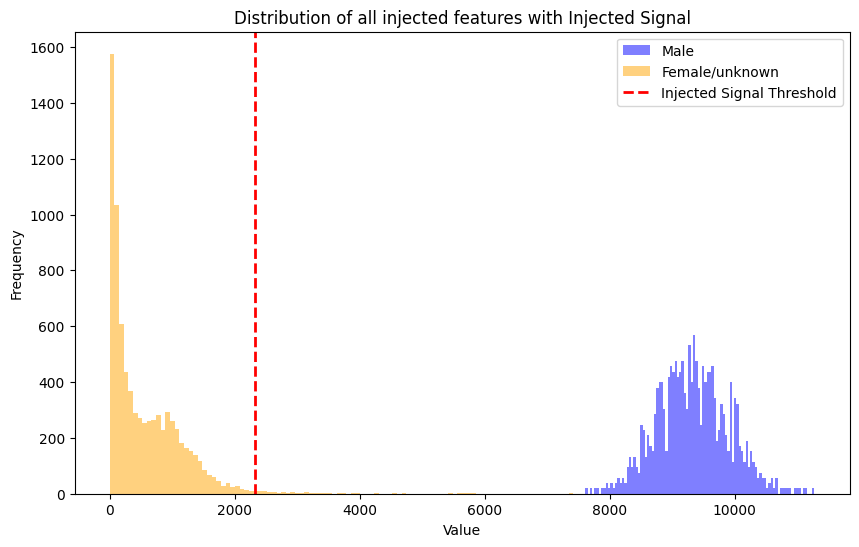

In [ ]:
# Plot the distribution of the modified features compared to all features
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_rna.loc[sample_synth,feature_synth].stack(), bins=100, alpha=0.5, label="Male", color="blue")
plt.hist(df_rna.loc[~df_rna.index.isin(sample_synth), feature_synth].stack(), bins=100, alpha=0.5, label="Female/unknown", color="orange")

plt.axvline(
	df_rna.stack().quantile(0.9),
	color="red",
	linestyle="dashed",
	linewidth=2,
	label="Injected Signal Threshold",
)
plt.title(f"Distribution of all injected features with Injected Signal")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 2b) Train an Ontix on the data set with synthetic signal.

In [5]:
import os
import autoencodix as acx
from autoencodix.configs.default_config import DataConfig, DataInfo, DataCase
from autoencodix.configs import OntixConfig

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
data_root = "data/raw"
# rna_file = "combined_rnaseq_formatted.parquet"
# meth_file = "combined_meth_formatted.parquet"
# clin_file = "combined_clin_formatted.parquet"
rna_file = "combined_rnaseq_formatted_synth.parquet"
meth_file = "combined_meth_formatted_synth.parquet"
clin_file = "combined_clin_formatted.parquet"
ont_genelevel = "chromosome_ont_genelevel_ncbi.txt"
ont_hiddenlevel = "chromosome_ont_hiddenlevel.txt"
# ---------------------------------------------------------------------
# Define individual data modalities
# ---------------------------------------------------------------------
rna_info = DataInfo(
    file_path=os.path.join(data_root, rna_file),
    data_type="NUMERIC",
    filtering="VAR",
)

meth_info = DataInfo(
    file_path=os.path.join(data_root, meth_file),
    data_type="NUMERIC",
    filtering="VAR",
)

anno_info = DataInfo(
    file_path=os.path.join(data_root, clin_file),
    data_type="ANNOTATION",
)
# ---------------------------------------------------------------------
# Combine into DataConfig
# ---------------------------------------------------------------------
data_config = DataConfig(
    data_info={
        "RNA": rna_info,
        "METH": meth_info,
        "ANNO": anno_info,
    },
    annotation_columns=[
        # "CANCER_TYPE",
        "CANCER_TYPE_ACRONYM",
        # "TMB_NONSYNONYMOUS",
        # "AGE",
        # "OS_STATUS",
        # "GRADE",
        "SEX",
    ],
)

# ---------------------------------------------------------------------
# Define the full DefaultConfig (roughly equivalent to old cfg)
# ---------------------------------------------------------------------
ontix_config = OntixConfig(
    data_config=data_config,
    reproducible=True,
    global_seed=42,
    epochs=100,
    learning_rate=0.0005,
    batch_size=128,
    drop_p=0.3,
    k_filter=2000,
    latent_dim=6,
    # device="cpu",
    device="cuda",
    reconstruction_loss="mse",
    default_vae_loss="kl",
    beta=0.001,
    save_memory=False,
    scaling="MINMAX",
    train_ratio=0.7,
    test_ratio=0.2,
    valid_ratio=0.1,
)

# ---------------------------------------------------------------------
# Now pass into your Ontix object
# ---------------------------------------------------------------------

ont_files = [ont_hiddenlevel, ont_genelevel]
ont_files = [os.path.join(data_root, f) for f in ont_files]
ontix = acx.Ontix(
    ontologies=ont_files,
    config=ontix_config,
)

/home/ewald/Github/acx_main_releases/autoencodix_package/src/autoencodix/configs/default_config.py:433: UserWarning: annotation_columns in DataConfig is deprecated. Please set it directly in DefaultConfig instead.
  warnings.warn(


In [6]:
result = ontix.run()

reading parquet: data/raw/combined_rnaseq_formatted_synth.parquet
reading parquet: data/raw/combined_meth_formatted_synth.parquet
reading parquet: data/raw/combined_clin_formatted.parquet
anno key: paired
Features in feature_order not found in all_feature_names: ['100133144', '10357', '10431', '155060', '390284', '57714', '645851', '653553', '729884', '246182', '119385', '653268', '728404', '200810', '138649', '441425', '728747', '729171', '23520', '303', '304', '305', '244', '375719', '441432', '503640', '641522', '432369', '92270', '6791', '85319', '606', '23629', '286076', '414235', '170393', '255352', '283422', '283416', '374467', '84837', '400223', '650662', '280655', '283651', '80035', '283687', '196968', '284185', '147429', '147525', '494514', '574036', '284573', '149469', '84791', '253868', '284836', '54094', '54067', '282566', '114041', '114043', '149992', '55267', '29798', '348738', '339942', '93556', '646450', '317648', '92070', '79614', '153571', '116349', '441108', '285679

### Check if we have a little signal on Chromosome 21 (male/femal seperation)

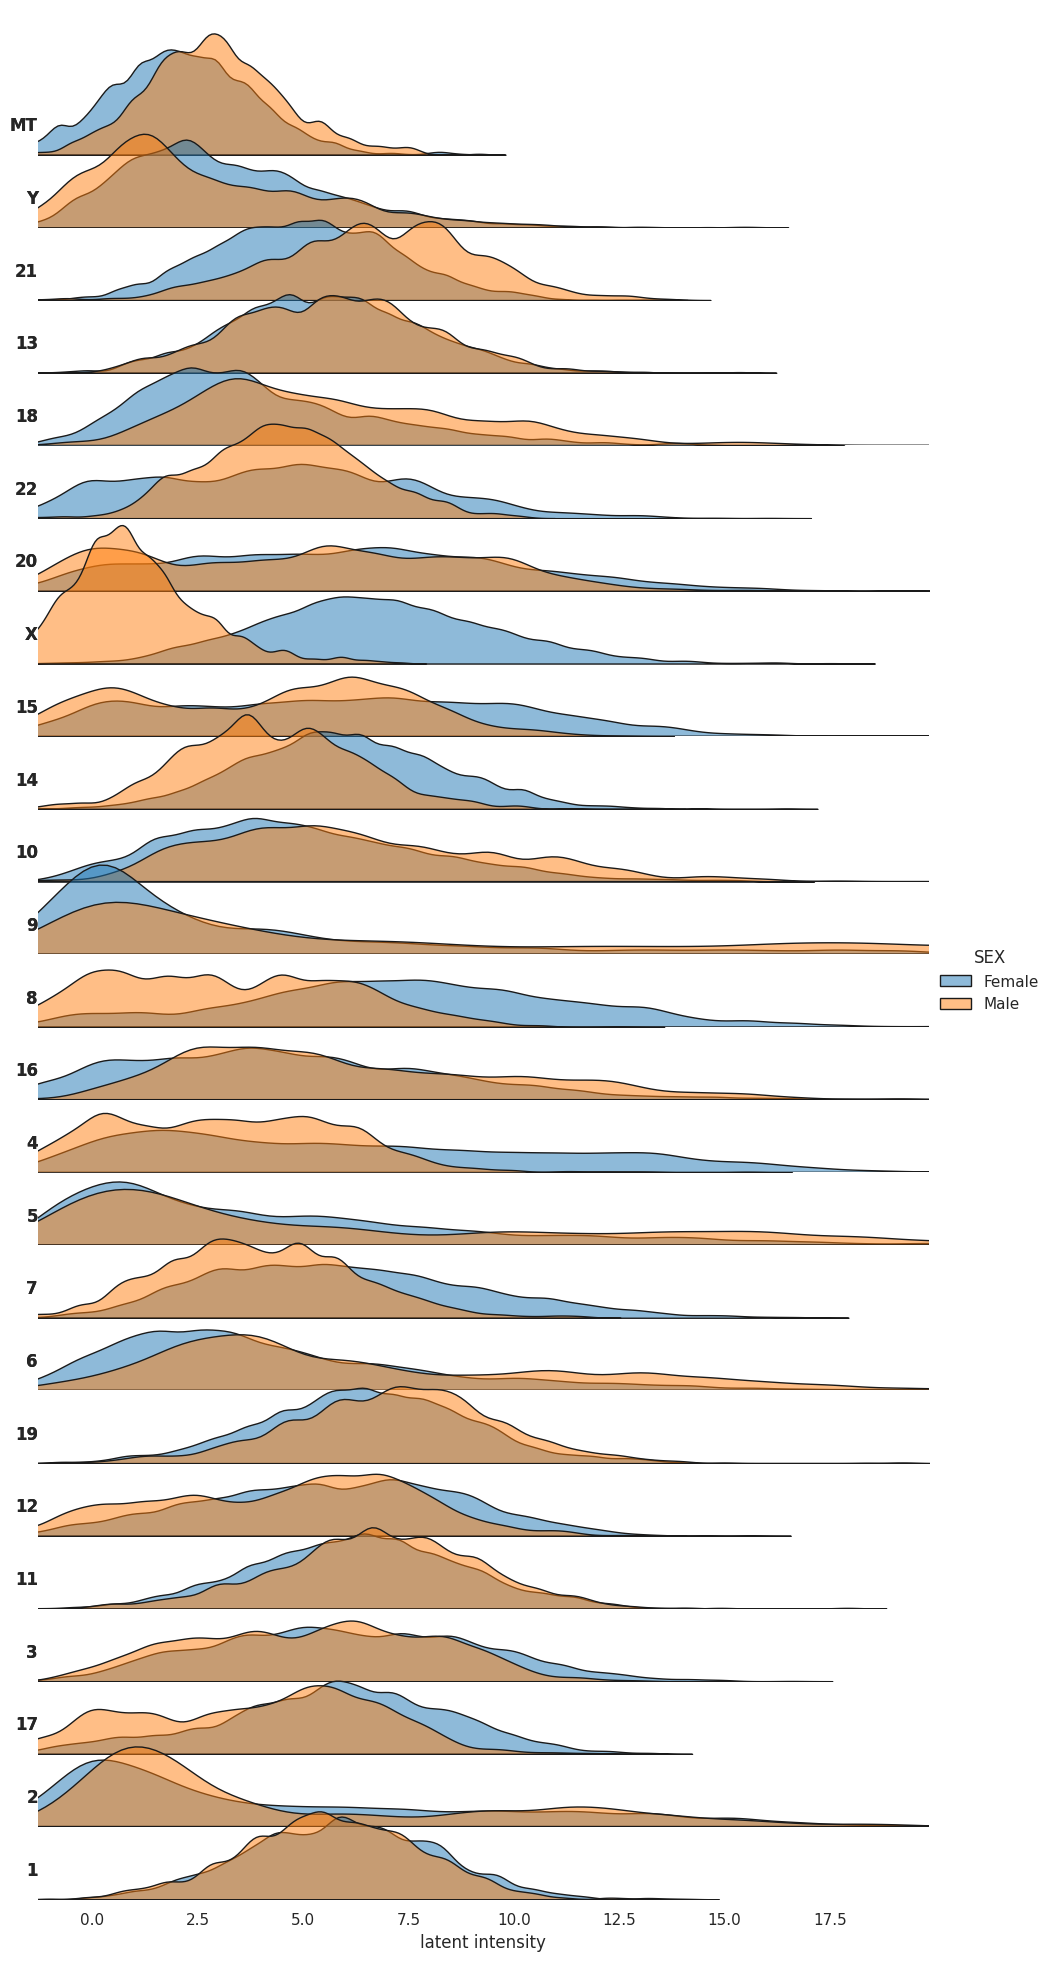

In [7]:
# ontix.show_result(params=["SEX"])
ontix.visualizer.show_latent_space(result=ontix.result, plot_type="Ridgeline", param=["SEX"])

##### Now we can call ontix.explain()
This will calculate gene-by-latent-dimension attribution scores. The explain step returns these as pd.DataFrame and also saves this DataFrame to `result.embedding_attributions`

In [9]:
# latent_contributions = ontix.explain()
latent_contributions = ontix.explain(
    method="DeepLiftShap", # "DeepLiftShap" or "IntegratedGradients"
    # sel_latent_dim=None, # To calculate contribution for all latent dimensions
    sel_latent_dim='21', # Or specify a single latent dimension to explain
	input_type="grouped", # We will test group 'Male' (input) vs. 'Female' (baseline)
	input_group="Male",
	baseline_type="grouped",
	baseline_group="Female",
	anno_col="SEX",
)

/home/ewald/Github/acx_main_releases/autoencodix_package/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Start feature attribution calculation
Calculating attributions for latent dimension: 2


/home/ewald/Github/acx_main_releases/autoencodix_package/.venv/lib/python3.10/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(


In [10]:
print(latent_contributions)

            21
8755  0.000410
6439  0.000139
1277  0.000194
2335  0.000635
1278  0.000314
...        ...
3229  0.001345
2322  0.004136
7539  0.003321
962   0.015129
8354  0.002853

[2000 rows x 1 columns]


In [11]:
latent_contributions.loc[:, ["21"]].sort_values(by="21", ascending=False)

,21
9185,4.276336e-02
1525,4.158988e-02
58494,4.089054e-02
26658,4.071428e-02
128646,4.040800e-02
...,...
135656,1.418938e-06
118430,1.338562e-06
70,1.145638e-06
27121,8.217619e-07


#### Now we can plot top 10 highest contribution scores of chromosome 21 and highlight features with synthetic signal
We see indeed that our groundtruth signal genes show the highest attribution scores


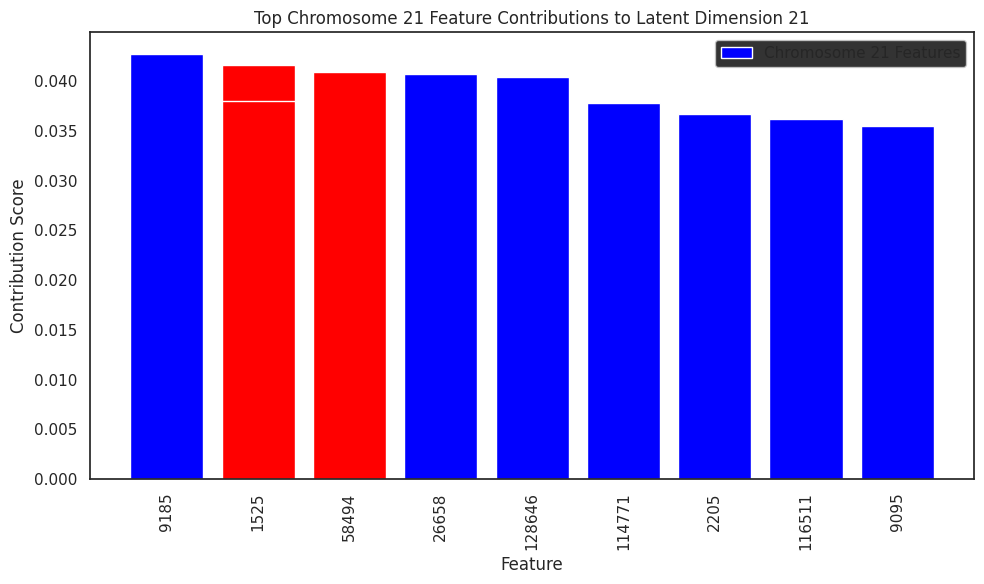

In [12]:
chrom_21_contributions = latent_contributions.loc[:, ["21"]].sort_values(by="21", ascending=False)[:10]

color_map = ["red" if feature in feature_synth else "blue" for feature in chrom_21_contributions.index]

plt.figure(figsize=(10, 6))
plt.bar(chrom_21_contributions.index, chrom_21_contributions.values.flatten(), color=color_map, label="Chromosome 21 Features")
plt.title("Top Chromosome 21 Feature Contributions to Latent Dimension 21")
plt.xlabel("Feature")
plt.ylabel("Contribution Score")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


        
### 3) How to Customize the Explain Step 
 
You have the follwong options:
```python
        method: Literal["DeepLiftShap", "IntegratedGradients"] = "DeepLiftShap",
        sel_latent_dim: Union[list, int, str, None] = None,
        input_type: Literal["random", "grouped"] = "grouped",
        input_group: Optional[str] = None,
        baseline_type: Literal["mean", "random", "grouped"] = "mean",
        baseline_group: str = "all",
        anno_col: Optional[str] = None,
        n_subset: int = 100,
        seed_int: int = 12,
        split: Literal["train", "test", "valid"] = "train",
        llm_explain: bool = False,
        llm_client: Literal["ollama", "mistral", "openrouter", "scads-llm"] = "mistral",
        llm_model: str = "mistral-large-latest",
        top_n_genes: int = 40,
        prompt: str = PROMPT,
```

**More Details on the Options:**

```python
        """Runs the feature-importance explainer and returns gene-by-latent-dimension attribution scores.

        Args:
            method:  Specifies which attribution algorithm to use for explaining the model.
            sel_latent_dim: Specifies which latent dimension(s) to explain. If None, all dimensions will be explained.
            input_type: Specifies whether the feature-importance algorithm should use 'random' samples or 'grouped' samples (see input_group) as input for the attribution computation.
            input_group: If input_type is 'grouped', this specifies which subset in anno_col to filter for to use as input for the attribution computation.
            baseline_type: Specifies whether the feature-importance algorithm should use the 'mean' baseline, a 'random'-sample baseline, or samples from a 'grouped' baseline (see baseline_group).
            baseline_group: Specifies whether the baseline is computed using all data (default) or which subset in anno_col to filter for.
            anno_col: If baseline_group is not 'all', this specifies the annotation column used to filter the baseline data.
            n_subset: Specifies the number of cells to use when subsampling for the attribution computation.
            seed_int: Defines the random seed used for reproducible subsampling and attribution calculations.
            split: The split to use for feature importance calculation (train, valid, test), default is train.
            llm_explain: Whether to use LLM explainers for feature importance calculation.
            llm_client: The LLM client to use for feature importance calculation.
            llm_model: The LLM model to use for feature importance calculation.
            top_n_genes: How many top (contribution to embedding) genes to consider for LLM explanation.

        Returns:
            pd.DataFrame: The generated samples in the input space.
                A DataFrame of attribution scores with genes as the index and latent dimensions as columns.
                Each entry represents the contribution of a given gene to a specific latent dimension.
        """
        ```

### 4) How To Use LLM to Get Insights of Gene Contributions
We can send the gene attribution score directly to an LLM and get biological insights for each latent dimension, i.e. latent dim 1 is associated with cell cylce ..
The LLM will give you and explanation for each latent dim and will save this in an extra markdown file. Additionally, we get  parsable JSON that is stored in `result.embedding_explanations`.  

Before, we can obtain this, we need to set up our LLM provider (in the future this might be provided by use)
See below how to do  this:


#### 🧬 Gene Expression Explanation – README
You can get LLM explanations from our  `.explain` step by setting `llm_explain=True`. Therefore you need to setup LLM Clients

You can use either:

* **Mistral API** (cloud-based)
* **Ollama** (local models running on your machine)
* **OpenRouter** (cloud-based)
* **ScaDS-LLM** (internal-LLM-server)



#### Requirements

Depending on if you want to use Mistral or Ollama you need to have:
- a Mistral API key
- Ollam installed and at least one model served


#### Environment Setup

##### 1. Using Mistral API

Set an API key in your `.env` file in the root of the repository

```
MISTRAL_API_KEY=your_api_key_here
```

**Models**

You may use any model served by Mistral, for example:

* `mistral-small-latest`
* `mistral-medium-latest`
* `mistral-large-latest`

Make sure the `model_name` you pass to `.explain` matches an available Mistral model.


##### 2. Using Ollama

Ollama runs models **locally**.
You must first install Ollama and pull the model you want:

```bash
ollama pull <model-name>
```


Your `model_name` must match exactly the name of the model served by Ollama:

* `qwen2.5:0.5b`
* `deepseek-r1:8b`

##### 3. Using Openrouter

To use a widespread options of models you can use Openrouter. For this simply set a environment variable in your terminal with: 

`export OPENROUTER_PREMIUM_API_KEY="sk-my-key"`

##### 4. Using ScaDS-LLM server

If you are a ScaDS.AI member or have a ZIH TU Dresden account, you can use our self-hosted LLM server (https://llm.scads.ai/docs/).

To enable this, set an environment variable like this: 

`export SCADS_LLM_API_KEY="sk-my-key"`



##### 🧬 Using `.explain()` for Gene Expression Interpretation

The `.explain()` method can generate a short biological explanation and hypothesis about what is happening in disease vs healthy samples given a list of altered genes.

### Example


In [14]:

ontix.explain(
	method="IntegratedGradients", # "DeepLiftShap" or "IntegratedGradients"
    # sel_latent_dim=None, # To calculate contribution for all latent dimensions
    sel_latent_dim=['21', 'X'], # Or specify a single latent dimension to explain
	input_type="grouped", # We will test group 'Male' (input) vs. 'Female' (baseline)
	input_group="Male",
	baseline_type="grouped",
	baseline_group="Female",
	anno_col="SEX",
    llm_explain=True,
    llm_client="openrouter",
    llm_model="gemma-4-31b-it",
    top_n_genes=10)

/home/ewald/Github/acx_main_releases/autoencodix_package/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Start feature attribution calculation
Calculating attributions for latent dimension: 2
Calculating attributions for latent dimension: 7
Start LLM explanation generation
Explaining latent dimension X with LLM...
Explaining latent dimension 21 with LLM...
Saved explanations to: /home/ewald/Github/acx_main_releases/autoencodix_package/latent_explanations.md


,21,X
8755,0.000434,0.000608
6439,0.000218,0.000231
1277,0.000247,0.000566
2335,0.000747,0.000988
1278,0.000391,0.000766
...,...,...
3229,0.001973,0.005991
2322,0.004055,0.008223
7539,0.003087,0.006265
962,0.015750,0.005568


This creates a verbal descriptions which is stored in the file `latent_explanations.md` as markdown document with an output like this:

# Latent Dimension X

## Most influential genes
3597, 399668, 9949, 9185, 58494, 2010, 55613, 56180, 9968, 9130

## TLDR
This latent dimension likely represents the coordination of RNA processing, splicing, and nuclear transport mechanisms essential for cellular gene expression regulation.

## Details

### Dominant Biological Themes

The provided gene set is heavily enriched for components of the spliceosome, RNA-binding proteins, and nuclear pore complex components, indicating a strong theme of mRNA maturation and nucleocytoplasmic transport.

### Mechanistic Hypotheses

- The dimension captures a regulatory program governing the efficiency of pre-mRNA splicing and export to the cytoplasm.

- This dimension may represent a cellular state characterized by high transcriptional activity requiring robust RNA processing machinery.

### Summary of Pathways/Processes

Key implicated processes include the Spliceosome (KEGG), RNA transport (GO), and mRNA processing (GO), focusing on the transition of genetic information from the nucleus to the ribosome.


---

# Latent Dimension 21

## Most influential genes
9185, 58494, 1525, 1525, 399668, 9130, 128646, 2010, 9949, 56180

## TLDR
This latent dimension likely represents a cellular state focused on protein synthesis, ribosomal biogenesis, and basic metabolic maintenance.

## Details

### Dominant Biological Themes

The gene set is dominated by components of the translational machinery, specifically ribosomal proteins and factors involved in protein folding and synthesis.

### Mechanistic Hypotheses

- The dimension captures the global translational capacity or protein synthesis rate of the cells.

- The dimension represents a metabolic shift toward anabolic growth and ribosomal biogenesis.

### Summary of Pathways/Processes

Implicated processes include Ribosome biogenesis (GO:0000154), Translation (GO:0006412), and Protein folding (GO:0006457).


---
